### Importación de datos



In [38]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda4.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175


##1. Análisis de facturación



In [33]:
IngresoTotal_tienda = tienda["Precio"].sum()
IngresoTotal_tienda2 = tienda2["Precio"].sum()
IngresoTotal_tienda3 = tienda3["Precio"].sum()
IngresoTotal_tienda4 = tienda4["Precio"].sum()

print("Ingreso total de la tienda 1: ", IngresoTotal_tienda)
print("Ingreso total de la tienda 2: ", IngresoTotal_tienda2)
print("Ingreso total de la tienda 3: ", IngresoTotal_tienda3)
print("Ingreso total de la tienda 4: ", IngresoTotal_tienda4)







Ingreso total de la tienda 1:  1150880400.0
Ingreso total de la tienda 2:  1116343500.0
Ingreso total de la tienda 3:  1098019600.0
Ingreso total de la tienda 4:  1038375700.0


In [ ]:
#Grafico Ingreso Total por tienda
ingresos = [IngresoTotal_tienda, IngresoTotal_tienda2, IngresoTotal_tienda3, IngresoTotal_tienda4]
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

plt.figure(figsize=(12, 5))
plt.title('Ingreso Total por Tienda')
barras = plt.bar(tiendas, ingresos, color='lightgreen')
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"${altura:,.2f}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
plt.show()

## 2. Ventas por categoría





In [34]:
# Tienda 1
Conteo_por_categoria = tienda.groupby("Categoría del Producto")["Precio"].count().sort_values(ascending=False).rename("Total")
print(" Tienda 1")
display(Conteo_por_categoria.head(5))

# Tienda 2
Conteo_por_categoria2 = tienda2.groupby("Categoría del Producto")["Precio"].count().sort_values(ascending=False).rename("Total")
print(" Tienda 2")
display(Conteo_por_categoria2.head(5))

# Tienda 3
Conteo_por_categoria3 = tienda3.groupby("Categoría del Producto")["Precio"].count().sort_values(ascending=False).rename("Total")
print(" Tienda 3")
display(Conteo_por_categoria3.head(5))

# Tienda 4
Conteo_por_categoria4 = tienda4.groupby("Categoría del Producto")["Precio"].count().sort_values(ascending=False).rename("Total")
print(" Tienda 4")
display(Conteo_por_categoria4.head(5))


df1 = Conteo_por_categoria.head(5).reset_index()
df1["Tienda"] = "Tienda 1"

df2 = Conteo_por_categoria2.head(5).reset_index()
df2["Tienda"] = "Tienda 2"

df3 = Conteo_por_categoria3.head(5).reset_index()
df3["Tienda"] = "Tienda 3"

df4 = Conteo_por_categoria4.head(5).reset_index()
df4["Tienda"] = "Tienda 4"



 Tienda 1


,Total
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284


 Tienda 2


,Total
Categoría del Producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275


 Tienda 3


,Total
Categoría del Producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277


 Tienda 4


,Total
Categoría del Producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254


In [ ]:
# Grafico de ventas por categoria y tienda
top_categorias = pd.concat([df1, df2, df3, df4])
pivot = top_categorias.pivot(index="Categoría del Producto", columns="Tienda", values="Total").fillna(0)
pivot.plot(kind="bar", stacked=True, figsize=(12,6), colormap="viridis")

plt.title("Distribución de Ventas por Categoría y Tienda")
plt.xlabel("Categoría del Producto")
plt.ylabel("Cantidad Vendida")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tienda")
plt.show()

## 3. Calificación promedio de la tienda


In [ ]:
promedio_tienda1 = tienda["Calificación"].mean()
promedio_tienda2 = tienda2["Calificación"].mean()
promedio_tienda3 = tienda3["Calificación"].mean()
promedio_tienda4 = tienda4["Calificación"].mean()
Pomedio_Calificacion_tienda = pd.DataFrame({'Tienda 1': [promedio_tienda1],'Tienda 2': [promedio_tienda2],'Tienda 3': [promedio_tienda3],'Tienda 4': [promedio_tienda4]})
Pomedio_Calificacion_tienda_sorted = Pomedio_Calificacion_tienda.T.sort_values(by=0, ascending=False)
Pomedio_Calificacion_tienda_sorted.columns = ['Promedio de Calificación']

display(Pomedio_Calificacion_tienda_sorted)

## 4. Productos más y menos vendidos

In [35]:
# Productos más y menos vendidos
ventas_tienda1 = tienda["Producto"].value_counts().reset_index()
ventas_tienda1.columns = ["Producto", "Cantidad Vendida"]
ventas_tienda2 = tienda2["Producto"].value_counts().reset_index()
ventas_tienda2.columns = ["Producto", "Cantidad Vendida"]
ventas_tienda3 = tienda3["Producto"].value_counts().reset_index()
ventas_tienda3.columns = ["Producto", "Cantidad Vendida"]
ventas_tienda4 = tienda4["Producto"].value_counts().reset_index()
ventas_tienda4.columns = ["Producto", "Cantidad Vendida"]

print("Productos más vendidos por tienda:")
display(ventas_tienda1.head(5),ventas_tienda2.head(5),ventas_tienda3.head(5),ventas_tienda4.head(5))
print("Productos menos vendidos por tienda:")
display(ventas_tienda1.tail(5),ventas_tienda2.tail(5),ventas_tienda3.tail(5),ventas_tienda4.tail(5))



Productos más vendidos por tienda:


,Producto,Cantidad Vendida
0,Microondas,60
1,TV LED UHD 4K,60
2,Armario,60
3,Secadora de ropa,58
4,Mesa de noche,56


,Producto,Cantidad Vendida
0,Iniciando en programación,65
1,Microondas,62
2,Batería,61
3,Guitarra acústica,58
4,Pandereta,58


,Producto,Cantidad Vendida
0,Kit de bancas,57
1,Mesa de comedor,56
2,Cama king,56
3,Set de ollas,55
4,Mesa de noche,55


,Producto,Cantidad Vendida
0,Cama box,62
1,Cubertería,59
2,Dashboards con Power BI,56
3,Cama king,56
4,Carrito de control remoto,55


Productos menos vendidos por tienda:


,Producto,Cantidad Vendida
46,Ciencia de datos con Python,39
47,Pandereta,36
48,Olla de presión,35
49,Auriculares con micrófono,33
50,Celular ABXY,33


,Producto,Cantidad Vendida
46,Auriculares,37
47,Sillón,35
48,Mesa de comedor,34
49,Impresora,34
50,Juego de mesa,32


,Producto,Cantidad Vendida
46,Guitarra eléctrica,38
47,Set de vasos,36
48,Mochila,36
49,Microondas,36
50,Bloques de construcción,35


,Producto,Cantidad Vendida
46,Refrigerador,38
47,Ciencia de datos con Python,38
48,Guitarra acústica,37
49,Armario,34
50,Guitarra eléctrica,33


## 5. Envío promedio por tienda

In [41]:
Costo_envio_tienda =tienda['Costo de envío'].mean()
Costo_envio_tienda2 =tienda2['Costo de envío'].mean()
Costo_envio_tienda3 =tienda3['Costo de envío'].mean()
Costo_envio_tienda4 =tienda4['Costo de envío'].mean()
print("COSTO DE ENVÍO PROMEDIO")
costos = [Costo_envio_tienda, Costo_envio_tienda2, Costo_envio_tienda3, Costo_envio_tienda4]
for i, costo in enumerate(costos, 1):
    print(f"   Tienda {i}: ${costo} ")


COSTO DE ENVÍO PROMEDIO
   Tienda 1: $26018.60958033065 
   Tienda 2: $25216.235693090293 
   Tienda 3: $24805.680373039424 
   Tienda 4: $23459.457167090754 


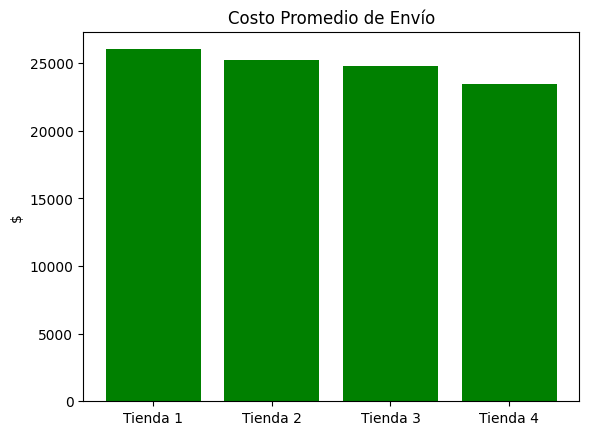

In [42]:
#Grafico Costo Promedio de Envio por tienda
costos = [Costo_envio_tienda, Costo_envio_tienda2, Costo_envio_tienda3, Costo_envio_tienda4]
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

plt.bar(tiendas, costos, color='Green')
plt.title('Costo Promedio de Envío')
plt.ylabel('$')
plt.show()

# Informe final
En este informe se detalla cual de las cuatro tiendas deberia vender el Sr Juan. La decisión se basa en un análisis riguroso de indicadores financieros, operativos y de satisfacción del cliente, buscando identificar la unidad menos eficiente y estratégicamente prescindible.

**1. Ingreso total por tienda:**


*   Tienda 1:  1150880400.0
*   Tienda 2:  1116343500.0
*   Tienda 3:  1098019600.0
*   Tienda 4:  1038375700.0

**Conclusion:** La Tienda 4 es la menos eficiente en la generación de ingresos, situándose significativamente por debajo de la T1

**2. Ventas por categoría**

-Tienda 3 (T3): Liderazgo en el Hogar (Alto Valor)

-Tienda 1 (T1): Potencia de Venta Masiva

-Tienda 2 (T2): Nicho de Especialización Digital

-Tienda 4 (T4): Los juguetes, aunque generan volumen, históricamente tienen márgenes de ganancia más bajos que Muebles o Electrónicos.

**Conclusión:** Esto indica que el alto volumen de ventas de la T4 se concentra en artículos de bajo valor o bajo margen (como Juguetes).

**3. Calificación promedio**

El promedio de calificaciones de satisfacción por tienda es:

Tienda 3: 4.048

Tienda 2: 4.037

Tienda 4: 3.996

Tienda 1: 3.977

**Conclusión:** La Tienda 4 ocupa el tercer lugar en satisfacción, mientras que la Tienda 1 tiene la calificación más baja.

**4. Envío promedio por tienda**

El costo de envío promedio pagado por los usuarios:

Tienda 1: $26,018.61

Tienda 2: $25,216.24

Tienda 3: $24,805.68

Tienda 4: $23,459.46


Observación: La Tienda 4 tiene los costos de envío más bajos, lo que podría ser una ventaja competitiva, pero también podría indicar estrategias de precios menos agresivas.
#**Conclusión y Recomendación**
Se recomienda al Sr. Juan vender la Tienda 4.

La Tienda 4 es la menos eficiente en el factor más importante: tiene el Ingreso Total más bajo (4° puesto). Venderla minimiza el impacto en el flujo de caja global de Alura Store.

Al vender T4, el Sr. Juan retiene a la T1 (el mayor generador de ingresos), a la T3 (la mejor en servicio al cliente y calidad) y a la T2 (sólida en ingresos y líder en un nicho digital). La T4 es la más prescindible para mantener una cadena de valor diversificada y rentable.

Aunque es la menos rentable, sus métricas operativas (Costo de Envío Promedio más bajo) y su nicho en Juguetes la convierten en un activo atractivo para un comprador, asegurando una transacción más rápida.

En conclusión, la venta de la Tienda 4 permite al Sr. Juan capitalizar su inversión liberando la unidad de menor rendimiento financiero, mientras mantiene la estabilidad y el potencial de crecimiento de las tiendas líderes.





